<a href="https://colab.research.google.com/github/ChathumDeeparaj/coffee-quality-analysis/blob/main/DataScience_Assigment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the data
df = pd.read_csv('/content/drive/MyDrive/DataScienceAssignment/arabica_data_cleaned.csv')

# Initial exploration
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn info:")
print(df.info())

# Select relevant columns for  analysis
# Based on research question about altitude, processing method, and species
columns_to_keep = [
    'Species',
    'Country.of.Origin',
    'Processing.Method',
    'Aroma',
    'Flavor',
    'Aftertaste',
    'Acidity',
    'Body',
    'Balance',
    'Uniformity',
    'Clean.Cup',
    'Sweetness',
    'Moisture',
    'Total.Cup.Points',
    'altitude_mean_meters'
]

df = df[columns_to_keep]

# Clean column names (remove dots, make lowercase)
df.columns = df.columns.str.replace('.', '_').str.lower()

print("\nColumns after cleaning:")
print(df.columns.tolist())

Dataset shape: (1311, 44)

First few rows:
   Unnamed: 0  Species                     Owner Country.of.Origin  \
0           1  Arabica                 metad plc          Ethiopia   
1           2  Arabica                 metad plc          Ethiopia   
2           3  Arabica  grounds for health admin         Guatemala   
3           4  Arabica       yidnekachew dabessa          Ethiopia   
4           5  Arabica                 metad plc          Ethiopia   

                                  Farm.Name Lot.Number       Mill ICO.Number  \
0                                 metad plc        NaN  metad plc  2014/2015   
1                                 metad plc        NaN  metad plc  2014/2015   
2  san marcos barrancas "san cristobal cuch        NaN        NaN        NaN   
3     yidnekachew dabessa coffee plantation        NaN    wolensu        NaN   
4                                 metad plc        NaN  metad plc  2014/2015   

                                 Company       Altitude

In [ ]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# For altitude, drop rows with missing values (can't estimate this)
df = df.dropna(subset=['altitude_mean_meters'])

# For processing method, fill missing with 'Unknown'
df['processing_method'] = df['processing_method'].fillna('Unknown')

# For sensory scores, fill with mean (small number of missing)
sensory_cols = ['aroma', 'flavor', 'aftertaste', 'acidity', 'body',
                'balance', 'uniformity', 'clean_cup', 'sweetness', 'moisture']
for col in sensory_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
species                   0
country_of_origin         1
processing_method       152
aroma                     0
flavor                    0
aftertaste                0
acidity                   0
body                      0
balance                   0
uniformity                0
clean_cup                 0
sweetness                 0
moisture                  0
total_cup_points          0
altitude_mean_meters    227
dtype: int64

Missing values after cleaning:
species                 0
country_of_origin       0
processing_method       0
aroma                   0
flavor                  0
aftertaste              0
acidity                 0
body                    0
balance                 0
uniformity              0
clean_cup               0
sweetness               0
moisture                0
total_cup_points        0
altitude_mean_meters    0
dtype: int64


In [ ]:
# Some altitudes might be in feet - check if conversion needed
# (data should already be in meters from the cleaned file)

# Remove impossible altitudes (highest point on Earth is 8848m)
df = df[df['altitude_mean_meters'] <= 8848]

# Remove altitude outliers (more than 3 standard deviations from mean)
z_scores = np.abs(stats.zscore(df['altitude_mean_meters'].dropna()))
df = df[z_scores < 3]

print(f"Rows after altitude cleaning: {len(df)}")

Rows after altitude cleaning: 1070


In [ ]:
# Create binary label for "good coffee" (>80 points is specialty grade)
df['quality_label'] = np.where(df['total_cup_points'] > 80, 'Good', 'Standard')

# Check distribution
print(df['quality_label'].value_counts())
print(f"\nGood coffee percentage: {df['quality_label'].value_counts(normalize=True)[1]:.2%}")

quality_label
Good        925
Standard    145
Name: count, dtype: int64

Good coffee percentage: 13.55%


/tmp/ipykernel_643/4168120691.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nGood coffee percentage: {df['quality_label'].value_counts(normalize=True)[1]:.2%}")


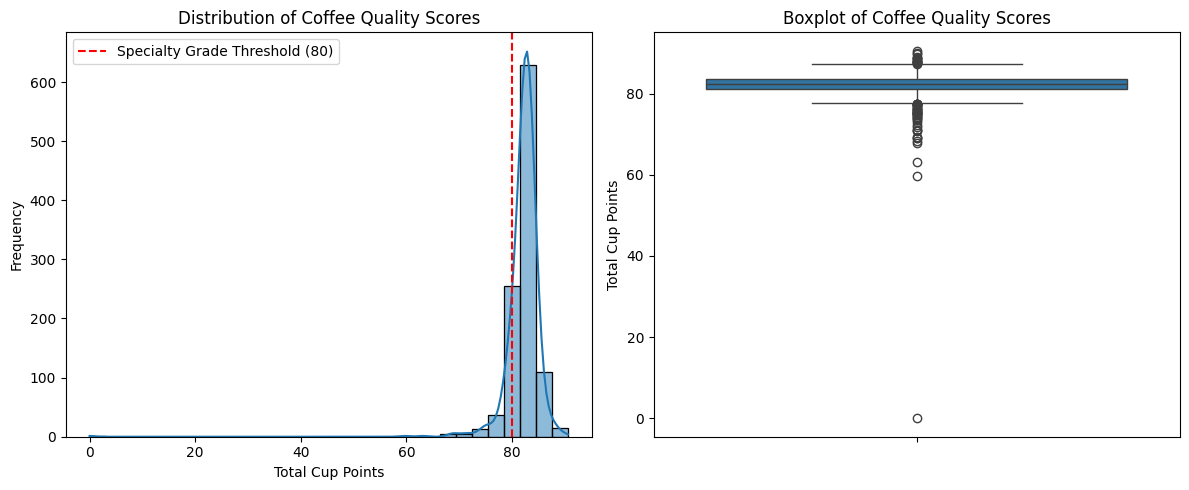

Quality Score Statistics:
count    1070.000000
mean       82.138897
std         3.650133
min         0.000000
25%        81.250000
50%        82.500000
75%        83.670000
max        90.580000
Name: total_cup_points, dtype: float64


In [ ]:
plt.figure(figsize=(12, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='total_cup_points', bins=30, kde=True)
plt.axvline(x=80, color='red', linestyle='--', label='Specialty Grade Threshold (80)')
plt.title('Distribution of Coffee Quality Scores')
plt.xlabel('Total Cup Points')
plt.ylabel('Frequency')
plt.legend()

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='total_cup_points')
plt.title('Boxplot of Coffee Quality Scores')
plt.ylabel('Total Cup Points')

plt.tight_layout()
plt.show()

# Summary statistics
print("Quality Score Statistics:")
print(df['total_cup_points'].describe())

In [ ]:
# Check how many zero values you have
zero_scores = df[df['total_cup_points'] == 0]
print(f"Number of samples with quality score = 0: {len(zero_scores)}")
print("\nSamples with zero quality score:")
print(zero_scores[['country_of_origin', 'processing_method', 'total_cup_points']])

# Check if there are any other suspiciously low values
low_scores = df[df['total_cup_points'] < 70]
print(f"\nNumber of samples with quality score < 70: {len(low_scores)}")
print(low_scores[['country_of_origin', 'processing_method', 'total_cup_points']].head())

Number of samples with quality score = 0: 1

Samples with zero quality score:
     country_of_origin processing_method  total_cup_points
1310          Honduras           Unknown               0.0

Number of samples with quality score < 70: 8
     country_of_origin processing_method  total_cup_points
1303          Honduras      Washed / Wet             69.33
1304          Honduras      Washed / Wet             69.17
1305          Honduras      Washed / Wet             69.17
1306            Mexico      Washed / Wet             68.33
1307             Haiti     Natural / Dry             67.92


In [ ]:
# Remove the zero score and very low scores
print(f"Original dataset size: {len(df)}")

# Remove the zero score sample
df = df[df['total_cup_points'] > 0]

# Remove samples below 70 (these are outliers in specialty coffee data)
df = df[df['total_cup_points'] >= 70]

print(f"Cleaned dataset size: {len(df)}")
print(f"Removed {1070 - len(df)} samples with invalid quality scores")

# Update quality labels
df['quality_label'] = np.where(df['total_cup_points'] > 80, 'Good', 'Standard')

# Recreate altitude categories
df['altitude_category'] = pd.cut(df['altitude_mean_meters'],
                                  bins=[0, 1000, 1500, 2000, 2500, 3000],
                                  labels=['<1000m', '1000-1500m', '1500-2000m',
                                          '2000-2500m', '>2500m'])

# Check new statistics
print("\nUpdated Quality Score Statistics:")
print(df['total_cup_points'].describe())

print(f"\nGood coffee (>80): {sum(df['total_cup_points'] > 80)} ({sum(df['total_cup_points'] > 80)/len(df)*100:.1f}%)")
print(f"Standard coffee (≤80): {sum(df['total_cup_points'] <= 80)} ({sum(df['total_cup_points'] <= 80)/len(df)*100:.1f}%)")

Original dataset size: 1070
Cleaned dataset size: 1062
Removed 8 samples with invalid quality scores

Updated Quality Score Statistics:
count    1062.000000
mean       82.318070
std         2.319376
min        70.750000
25%        81.330000
50%        82.580000
75%        83.670000
max        90.580000
Name: total_cup_points, dtype: float64

Good coffee (>80): 925 (87.1%)
Standard coffee (≤80): 137 (12.9%)


In [ ]:
# Verify no more issues
print("Minimum quality score now:", df['total_cup_points'].min())
print("Maximum quality score now:", df['total_cup_points'].max())

# Check distribution by country for the removed samples
removed_indices = [1303, 1304, 1305, 1306, 1307, 1310]  # From your earlier output
print(f"Removed indices: {removed_indices}")
print(f"Total removed: {len(removed_indices)}")

Minimum quality score now: 70.75
Maximum quality score now: 90.58
Removed indices: [1303, 1304, 1305, 1306, 1307, 1310]
Total removed: 6


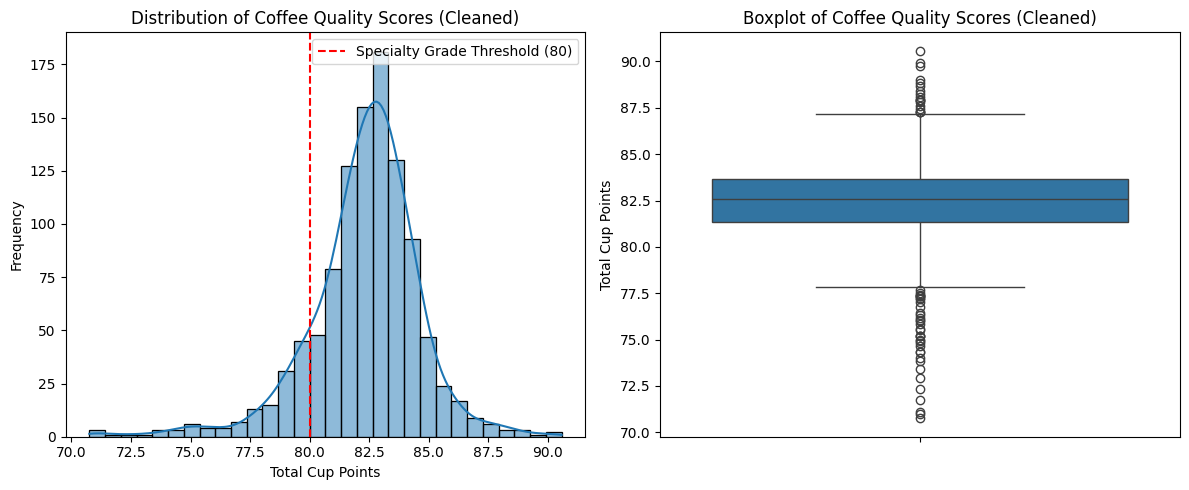

Quality Score Statistics (Cleaned):
count    1062.000000
mean       82.318070
std         2.319376
min        70.750000
25%        81.330000
50%        82.580000
75%        83.670000
max        90.580000
Name: total_cup_points, dtype: float64


In [ ]:
plt.figure(figsize=(12, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='total_cup_points', bins=30, kde=True)
plt.axvline(x=80, color='red', linestyle='--', label='Specialty Grade Threshold (80)')
plt.title('Distribution of Coffee Quality Scores (Cleaned)')
plt.xlabel('Total Cup Points')
plt.ylabel('Frequency')
plt.legend()

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='total_cup_points')
plt.title('Boxplot of Coffee Quality Scores (Cleaned)')
plt.ylabel('Total Cup Points')

plt.tight_layout()
plt.show()

print("Quality Score Statistics (Cleaned):")
print(df['total_cup_points'].describe())

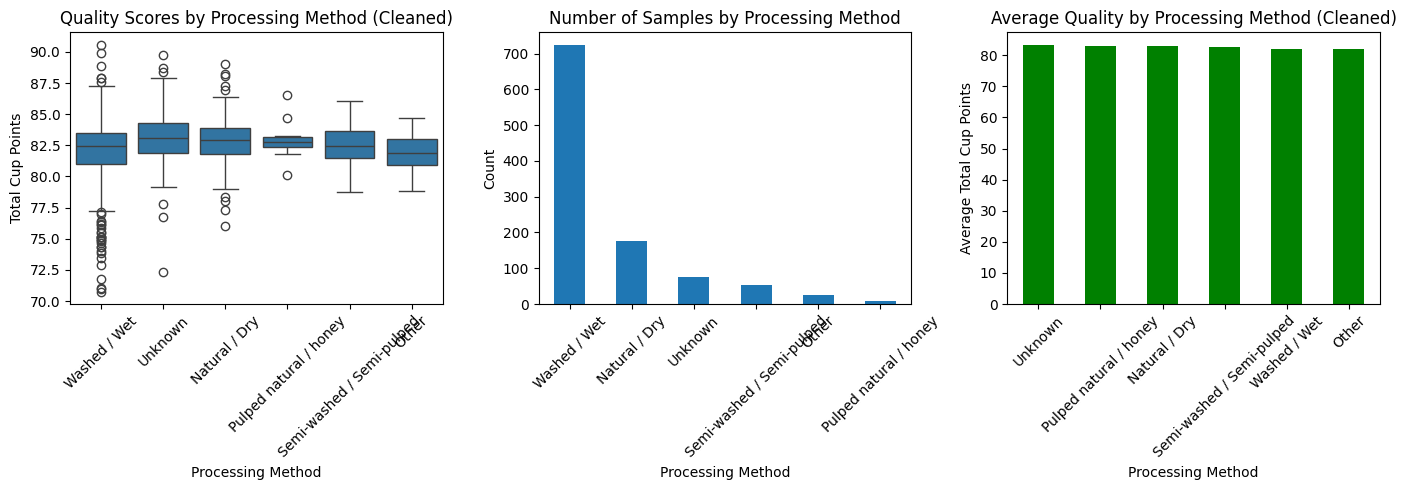


Average Quality Score by Processing Method (Cleaned):
                                mean  count       std
processing_method                                    
Unknown                    83.182338     77  2.645105
Pulped natural / honey     82.998000     10  1.709001
Natural / Dry              82.885114    176  1.846896
Semi-washed / Semi-pulped  82.566731     52  1.762765
Washed / Wet               82.069198    723  2.403990
Other                      82.062083     24  1.523280


In [ ]:
plt.figure(figsize=(14, 5))

# Boxplot by processing method
plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='processing_method', y='total_cup_points')
plt.title('Quality Scores by Processing Method (Cleaned)')
plt.xlabel('Processing Method')
plt.ylabel('Total Cup Points')
plt.xticks(rotation=45)

# Count of samples by processing method
plt.subplot(1, 3, 2)
method_counts = df['processing_method'].value_counts()
method_counts.plot(kind='bar')
plt.title('Number of Samples by Processing Method')
plt.xlabel('Processing Method')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Average quality by processing method
plt.subplot(1, 3, 3)
method_means = df.groupby('processing_method')['total_cup_points'].mean().sort_values(ascending=False)
method_means.plot(kind='bar', color='green')
plt.title('Average Quality by Processing Method (Cleaned)')
plt.xlabel('Processing Method')
plt.ylabel('Average Total Cup Points')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nAverage Quality Score by Processing Method (Cleaned):")
print(df.groupby('processing_method')['total_cup_points'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False))

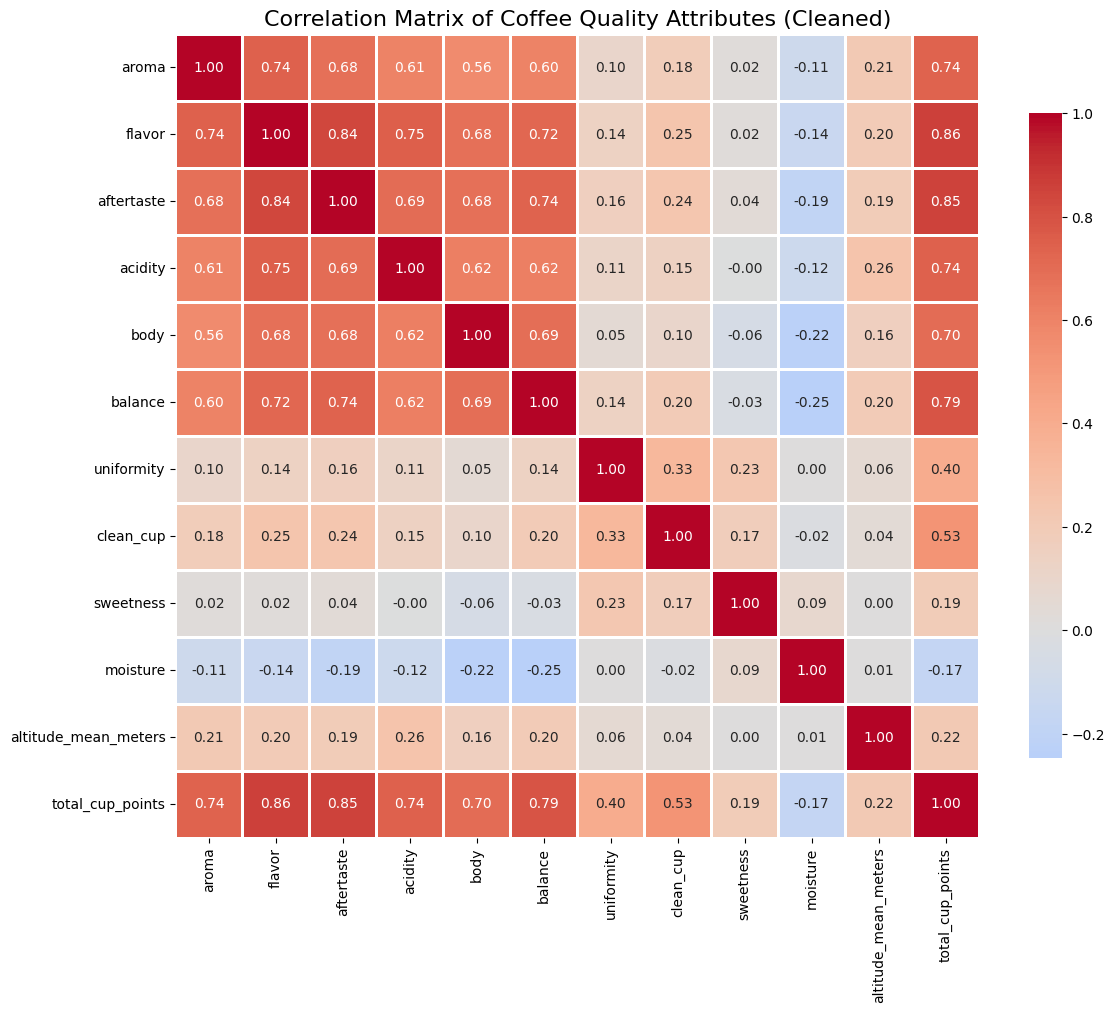


Correlation with Total Cup Points (Cleaned):
total_cup_points        1.000000
flavor                  0.862542
aftertaste              0.852779
balance                 0.786016
acidity                 0.743662
aroma                   0.738096
body                    0.702321
clean_cup               0.526008
uniformity              0.401904
altitude_mean_meters    0.215965
sweetness               0.193941
moisture               -0.169761
Name: total_cup_points, dtype: float64


In [ ]:
# Select numeric columns for correlation
numeric_cols = ['aroma', 'flavor', 'aftertaste', 'acidity', 'body',
                'balance', 'uniformity', 'clean_cup', 'sweetness',
                'moisture', 'altitude_mean_meters', 'total_cup_points']

# Correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.2f')
plt.title('Correlation Matrix of Coffee Quality Attributes (Cleaned)', fontsize=16)
plt.tight_layout()
plt.show()

# Correlations with total cup points
print("\nCorrelation with Total Cup Points (Cleaned):")
corr_with_target = corr_matrix['total_cup_points'].sort_values(ascending=False)
print(corr_with_target)

In [ ]:
# Prepare features
sensory_cols = ['aroma', 'flavor', 'aftertaste', 'acidity', 'body',
                'balance', 'uniformity', 'clean_cup', 'sweetness']
nonsensory_cols = ['altitude_mean_meters', 'moisture']

X_sensory = df[sensory_cols]
X_nonsensory = df[nonsensory_cols]
y = df['total_cup_points']

# Train-test split
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_sensory, y, test_size=0.3, random_state=42)
X_train_n, X_test_n, _, _ = train_test_split(
    X_nonsensory, y, test_size=0.3, random_state=42)

# Model 1: Linear Regression (Non-sensory)
lr_nonsensory = LinearRegression()
lr_nonsensory.fit(X_train_n, y_train)
lr_pred_n = lr_nonsensory.predict(X_test_n)

# Model 2: Linear Regression (Sensory)
lr_sensory = LinearRegression()
lr_sensory.fit(X_train_s, y_train)
lr_pred_s = lr_sensory.predict(X_test_s)

# Model 3: Random Forest (Sensory)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_s, y_train)
rf_pred = rf_model.predict(X_test_s)

# Comparison
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression (Altitude + Moisture)',
        'Linear Regression (Sensory)',
        'Random Forest (Sensory)'
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred_n),
        mean_absolute_error(y_test, lr_pred_s),
        mean_absolute_error(y_test, rf_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred_n)),
        np.sqrt(mean_squared_error(y_test, lr_pred_s)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    'R²': [
        r2_score(y_test, lr_pred_n),
        r2_score(y_test, lr_pred_s),
        r2_score(y_test, rf_pred)
    ]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON (Cleaned Data)")
print("="*60)
print(comparison.to_string(index=False))


MODEL PERFORMANCE COMPARISON (Cleaned Data)
                                  Model      MAE     RMSE       R²
Linear Regression (Altitude + Moisture) 1.533896 2.206512 0.028037
            Linear Regression (Sensory) 0.141440 0.271202 0.985317
                Random Forest (Sensory) 0.305573 0.534996 0.942860


/tmp/ipykernel_643/3047935590.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='altitude_category', y='total_cup_points', palette='viridis')


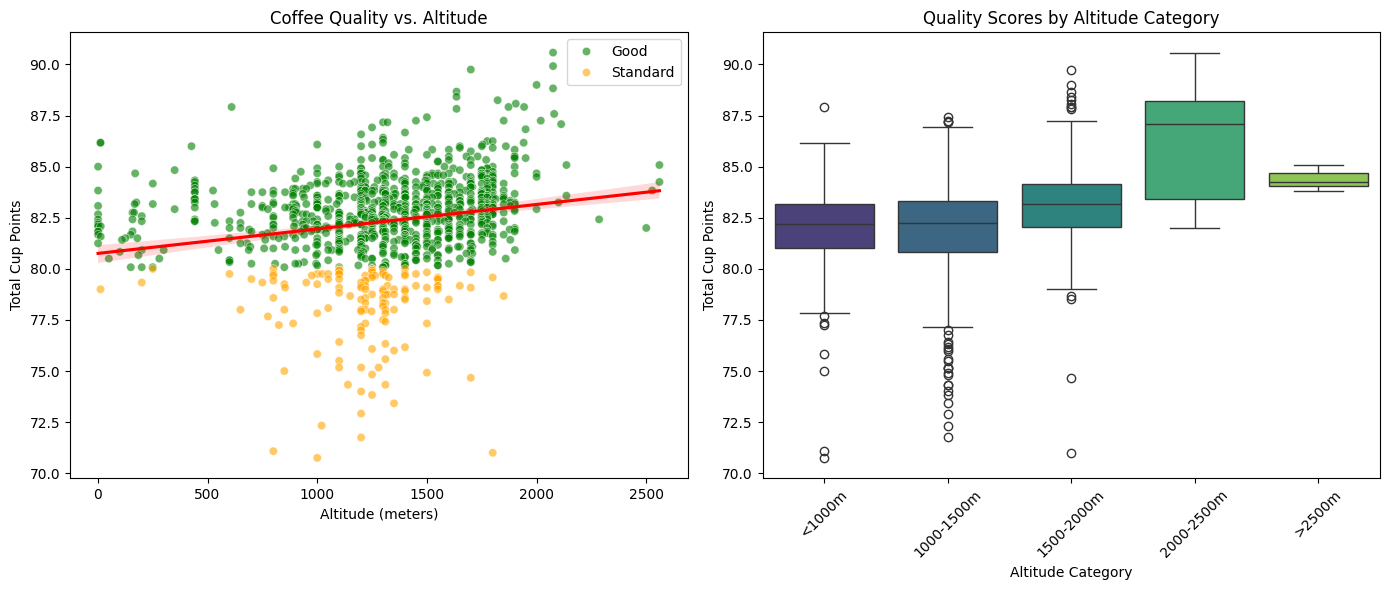

Correlation between altitude and quality: 0.216


In [ ]:
# Coffee Quality vs. Altitude
plt.figure(figsize=(14, 6))

# Scatter plot with regression line
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='altitude_mean_meters', y='total_cup_points',
                hue='quality_label', alpha=0.6, palette={'Good': 'green', 'Standard': 'orange'})
sns.regplot(data=df, x='altitude_mean_meters', y='total_cup_points',
            scatter=False, color='red', line_kws={'label': f'Regression Line (r={df["altitude_mean_meters"].corr(df["total_cup_points"]):.3f})'})
plt.title('Coffee Quality vs. Altitude')
plt.xlabel('Altitude (meters)')
plt.ylabel('Total Cup Points')
plt.legend()

# Boxplot by altitude categories
plt.subplot(1, 2, 2)
# Create altitude categories if not already done
df['altitude_category'] = pd.cut(df['altitude_mean_meters'],
                                  bins=[0, 1000, 1500, 2000, 2500, 3000],
                                  labels=['<1000m', '1000-1500m', '1500-2000m',
                                          '2000-2500m', '>2500m'])
sns.boxplot(data=df, x='altitude_category', y='total_cup_points', palette='viridis')
plt.title('Quality Scores by Altitude Category')
plt.xlabel('Altitude Category')
plt.ylabel('Total Cup Points')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('figure3_altitude_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print correlation
print(f"Correlation between altitude and quality: {df['altitude_mean_meters'].corr(df['total_cup_points']):.3f}")

/tmp/ipykernel_643/2511675350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='processing_method', y='total_cup_points', palette='Set2')


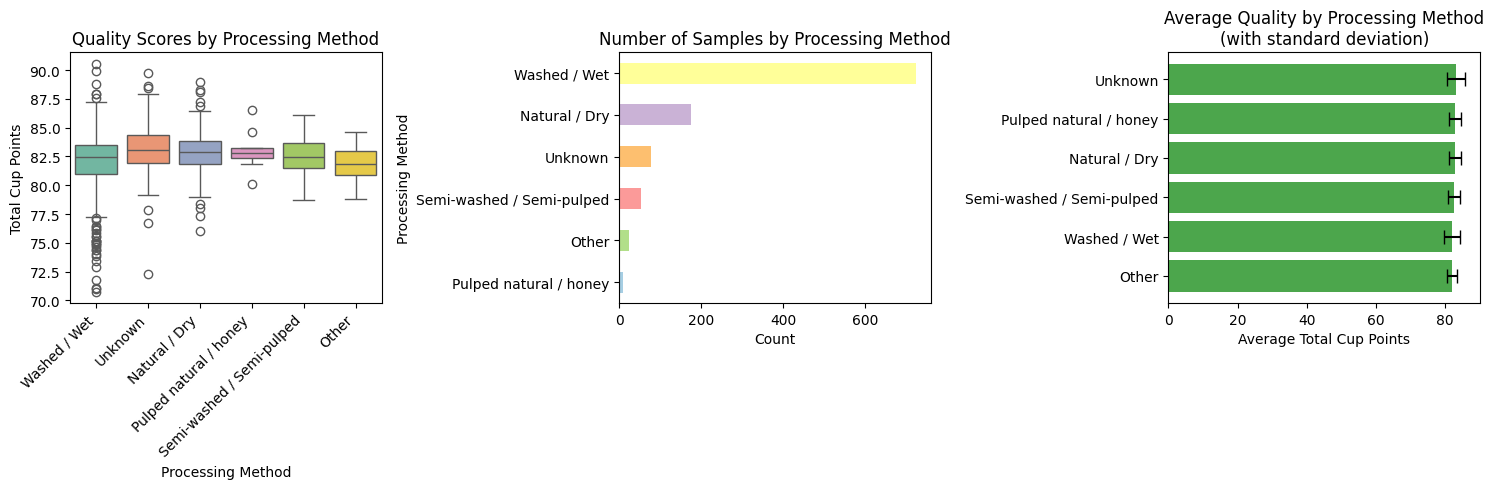


Average Quality Score by Processing Method:
                            mean  count   std
processing_method                            
Unknown                    83.18     77  2.65
Pulped natural / honey     83.00     10  1.71
Natural / Dry              82.89    176  1.85
Semi-washed / Semi-pulped  82.57     52  1.76
Washed / Wet               82.07    723  2.40
Other                      82.06     24  1.52


In [ ]:
# Quality Scores by Processing Method
plt.figure(figsize=(15, 5))

# Boxplot by processing method
plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='processing_method', y='total_cup_points', palette='Set2')
plt.title('Quality Scores by Processing Method')
plt.xlabel('Processing Method')
plt.ylabel('Total Cup Points')
plt.xticks(rotation=45, ha='right')

# Count of samples by processing method
plt.subplot(1, 3, 2)
method_counts = df['processing_method'].value_counts().sort_values(ascending=True)
colors = plt.cm.Paired(np.arange(len(method_counts))/len(method_counts))
method_counts.plot(kind='barh', color=colors)
plt.title('Number of Samples by Processing Method')
plt.xlabel('Count')
plt.ylabel('Processing Method')

# Average quality by processing method with error bars
plt.subplot(1, 3, 3)
method_stats = df.groupby('processing_method')['total_cup_points'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=True)
x_pos = np.arange(len(method_stats))
plt.barh(x_pos, method_stats['mean'], xerr=method_stats['std'],
         capsize=5, color='green', alpha=0.7)
plt.yticks(x_pos, method_stats.index)
plt.xlabel('Average Total Cup Points')
plt.title('Average Quality by Processing Method\n(with standard deviation)')

plt.tight_layout()
plt.savefig('figure4_processing_method.png', dpi=300, bbox_inches='tight')
plt.show()

# Print table
print("\nAverage Quality Score by Processing Method:")
print(df.groupby('processing_method')['total_cup_points'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False).round(2))

/tmp/ipykernel_643/2648195246.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='country_of_origin', y='total_cup_points', palette='coolwarm')


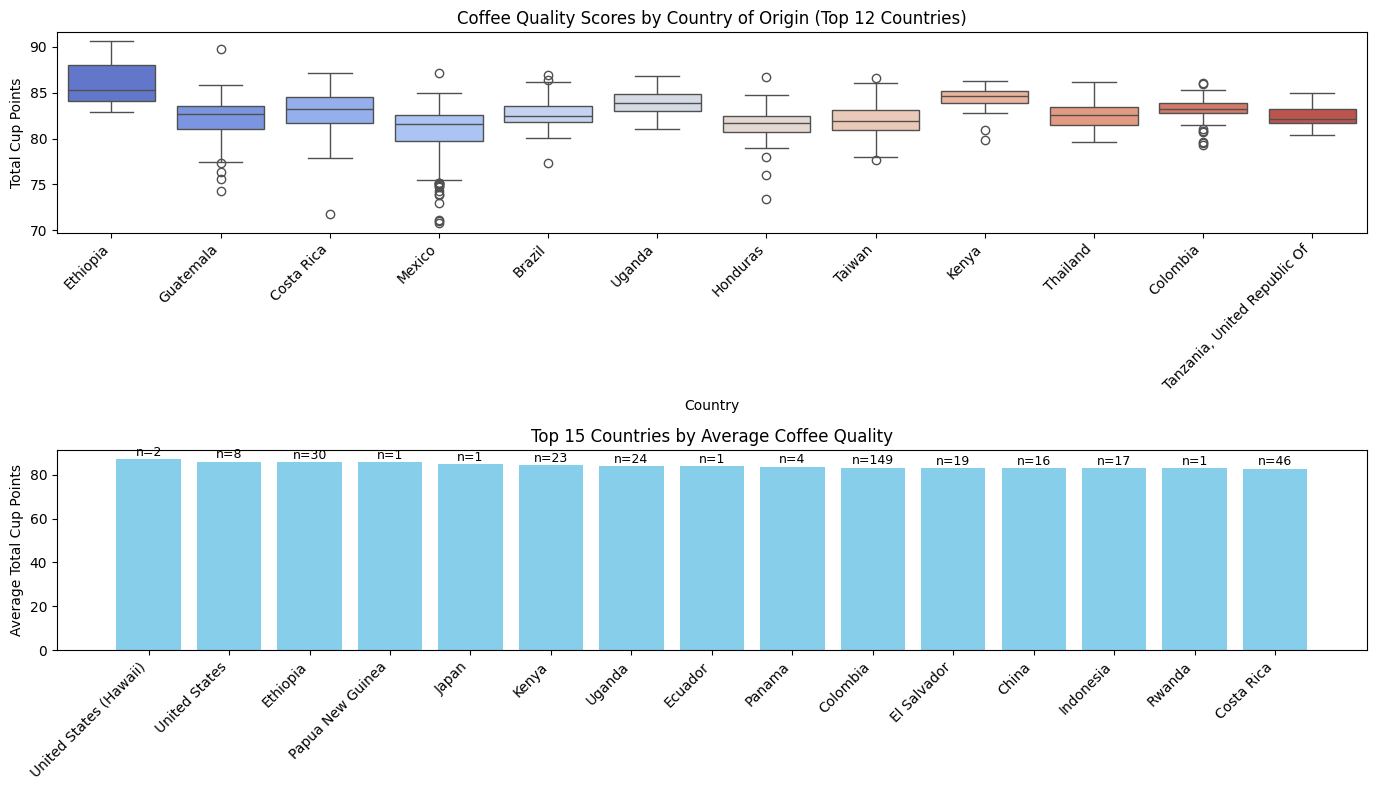


Top 15 Countries by Average Quality Score:
                             mean  count
country_of_origin                       
United States (Hawaii)  86.960000      2
United States           85.978750      8
Ethiopia                85.916333     30
Papua New Guinea        85.750000      1
Japan                   84.670000      1
Kenya                   84.271304     23
Uganda                  84.004167     24
Ecuador                 83.830000      1
Panama                  83.707500      4
Colombia                83.230403    149
El Salvador             83.115263     19
China                   82.927500     16
Indonesia               82.902353     17
Rwanda                  82.830000      1
Costa Rica              82.800435     46


In [ ]:
# Quality Scores by Country of Origin
# Get top 12 countries by sample count
top_countries = df['country_of_origin'].value_counts().head(12).index
df_top = df[df['country_of_origin'].isin(top_countries)]

plt.figure(figsize=(14, 8))

# Boxplot by country
plt.subplot(2, 1, 1)
sns.boxplot(data=df_top, x='country_of_origin', y='total_cup_points', palette='coolwarm')
plt.title('Coffee Quality Scores by Country of Origin (Top 12 Countries)')
plt.xlabel('Country')
plt.ylabel('Total Cup Points')
plt.xticks(rotation=45, ha='right')

# Mean scores with sample sizes
plt.subplot(2, 1, 2)
country_stats = df.groupby('country_of_origin')['total_cup_points'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(15)
countries = country_stats.index
means = country_stats['mean']
counts = country_stats['count']

# Create bar with count labels
bars = plt.bar(range(len(countries)), means, color='skyblue')
plt.xticks(range(len(countries)), countries, rotation=45, ha='right')
plt.ylabel('Average Total Cup Points')
plt.title('Top 15 Countries by Average Coffee Quality')

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'n={count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figure5_country_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print table
print("\nTop 15 Countries by Average Quality Score:")
print(country_stats.head(15))

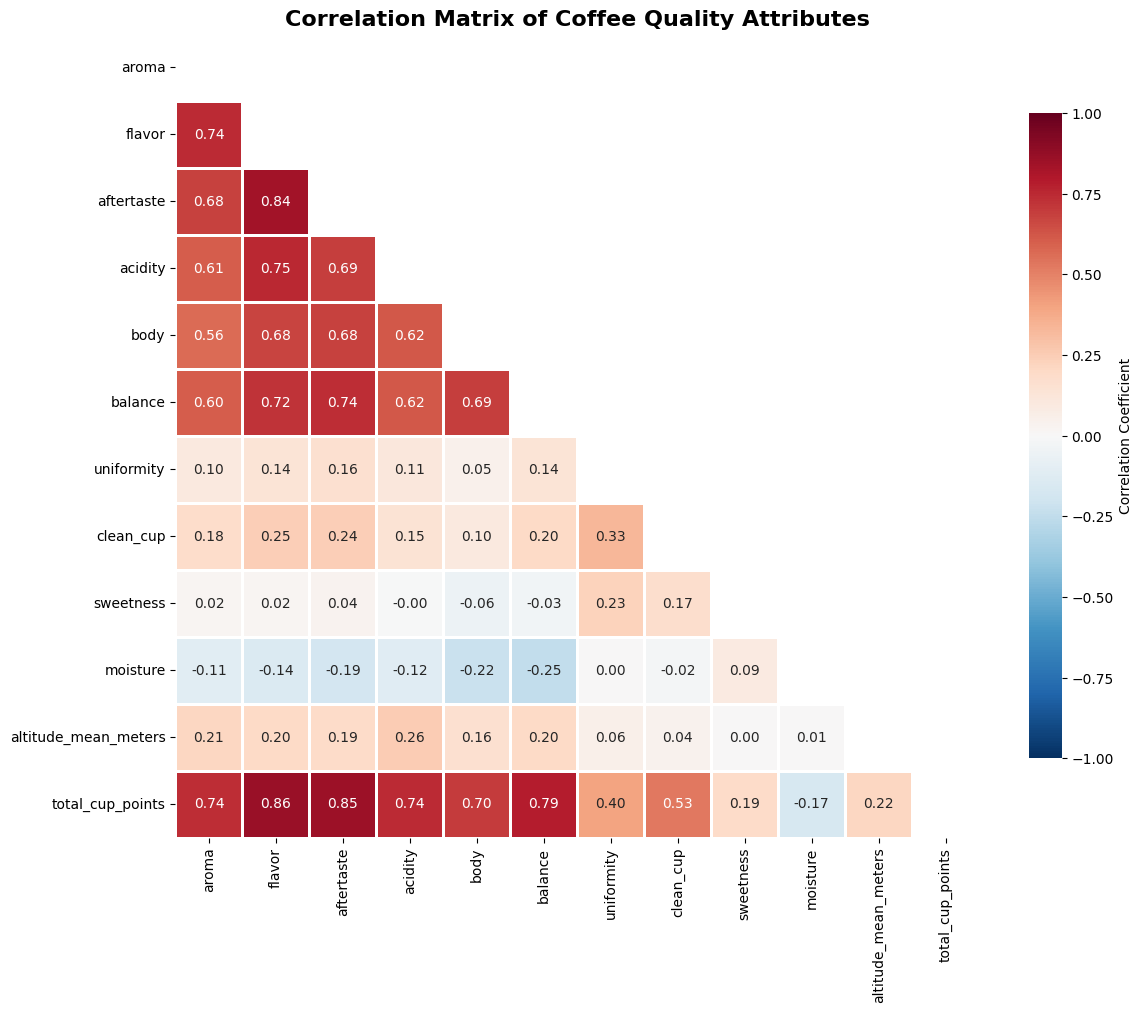


Correlation with Total Cup Points:
total_cup_points        1.000
flavor                  0.863
aftertaste              0.853
balance                 0.786
acidity                 0.744
aroma                   0.738
body                    0.702
clean_cup               0.526
uniformity              0.402
altitude_mean_meters    0.216
sweetness               0.194
moisture               -0.170
Name: total_cup_points, dtype: float64


In [ ]:
# Correlation Matrix
# Select numeric columns for correlation
numeric_cols = ['aroma', 'flavor', 'aftertaste', 'acidity', 'body',
                'balance', 'uniformity', 'clean_cup', 'sweetness',
                'moisture', 'altitude_mean_meters', 'total_cup_points']

# Correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()

# Create heatmap with better formatting
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            fmt='.2f', mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Coffee Quality Attributes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figure6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print correlations with target
print("\nCorrelation with Total Cup Points:")
corr_with_target = corr_matrix['total_cup_points'].sort_values(ascending=False)
print(corr_with_target.round(3))

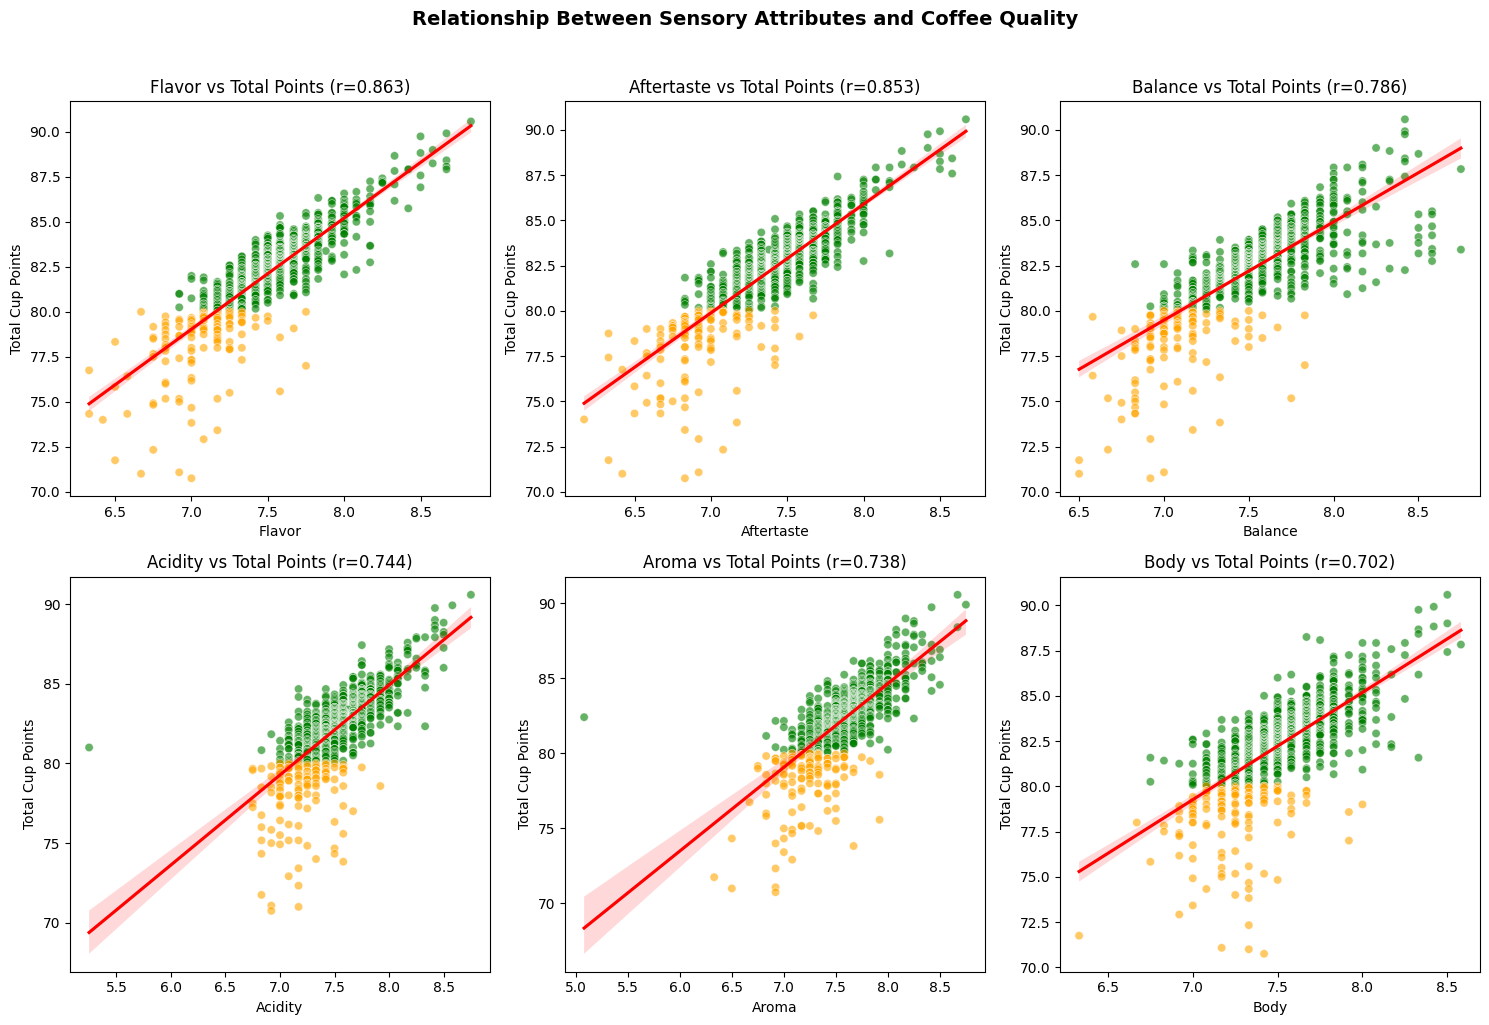

In [ ]:
# Scatter Plots of Key Attributes vs Total Cup Points
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Select top 6 features correlated with total_cup_points (excluding self-correlation)
top_features = corr_with_target.index[1:7]  # flavor, aftertaste, balance, acidity, aroma, body

for i, feature in enumerate(top_features):
    ax = axes[i]

    # Scatter plot with regression line
    sns.scatterplot(data=df, x=feature, y='total_cup_points',
                   hue='quality_label', alpha=0.6, ax=ax,
                   palette={'Good': 'green', 'Standard': 'orange'}, legend=False)

    # Add regression line
    sns.regplot(data=df, x=feature, y='total_cup_points',
               scatter=False, color='red', ax=ax)

    # Calculate correlation
    corr = df[feature].corr(df['total_cup_points'])

    ax.set_title(f'{feature.capitalize()} vs Total Points (r={corr:.3f})')
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel('Total Cup Points')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relationship Between Sensory Attributes and Coffee Quality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure7_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

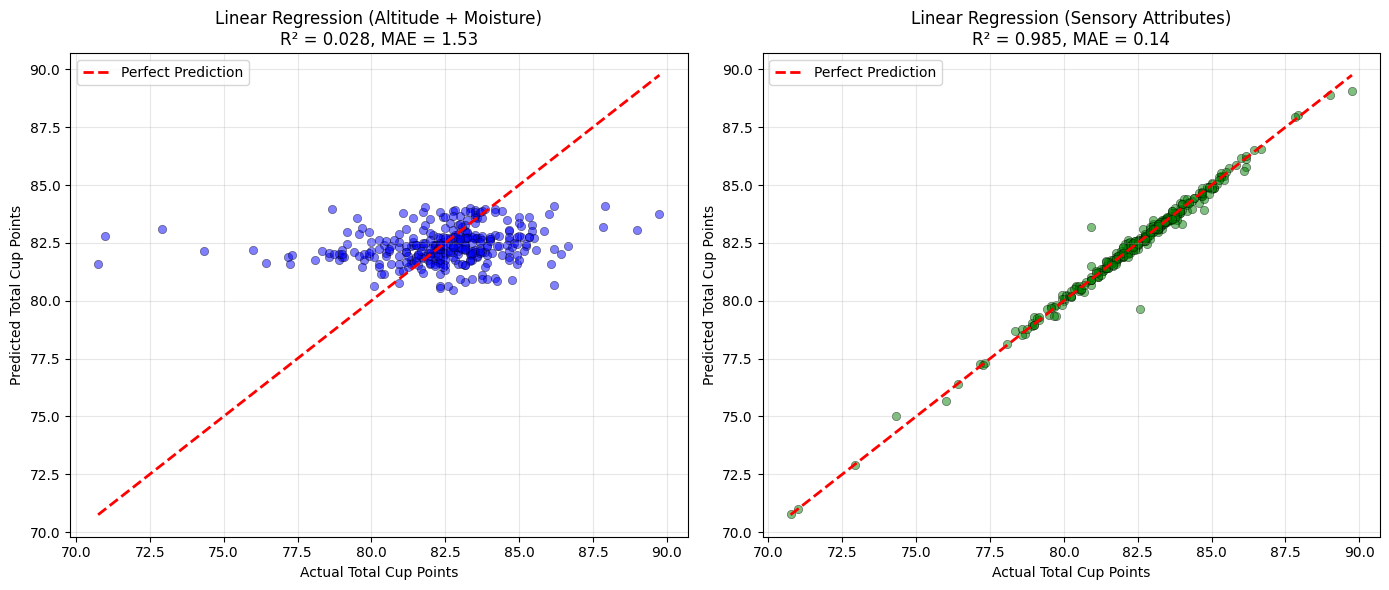

In [ ]:
# Linear Regression Performance
plt.figure(figsize=(14, 6))

# Predictions vs Actual for Environmental Model
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred_n, alpha=0.5, c='blue', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Total Cup Points')
plt.ylabel('Predicted Total Cup Points')
plt.title(f'Linear Regression (Altitude + Moisture)\nR² = {r2_score(y_test, lr_pred_n):.3f}, MAE = {mean_absolute_error(y_test, lr_pred_n):.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Predictions vs Actual for Sensory Model
plt.subplot(1, 2, 2)
plt.scatter(y_test, lr_pred_s, alpha=0.5, c='green', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Total Cup Points')
plt.ylabel('Predicted Total Cup Points')
plt.title(f'Linear Regression (Sensory Attributes)\nR² = {r2_score(y_test, lr_pred_s):.3f}, MAE = {mean_absolute_error(y_test, lr_pred_s):.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure8_linear_regression.png', dpi=300, bbox_inches='tight')
plt.show()

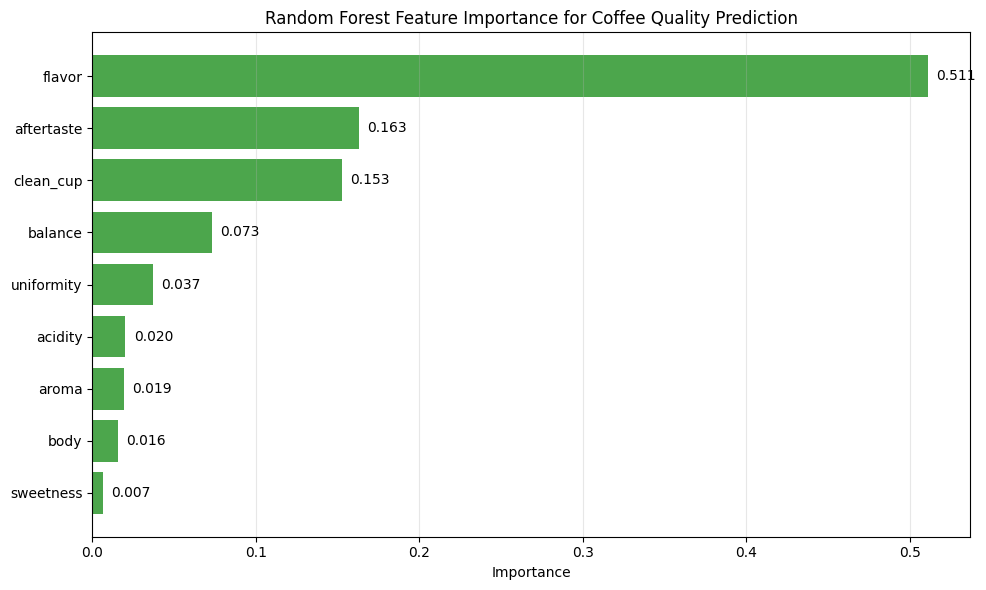


Feature Importance:
      feature  importance
1      flavor    0.511369
2  aftertaste    0.162966
7   clean_cup    0.152962
5     balance    0.073139
6  uniformity    0.037387
3     acidity    0.020340
0       aroma    0.019441
4        body    0.015806
8   sweetness    0.006590


In [ ]:
# Random Forest Feature Importance
plt.figure(figsize=(10, 6))

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': sensory_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

# Horizontal bar plot
plt.barh(feature_importance['feature'], feature_importance['importance'],
         color='green', alpha=0.7)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance for Coffee Quality Prediction')
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(feature_importance['importance']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('figure9_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature Importance:")
print(feature_importance.sort_values('importance', ascending=False))

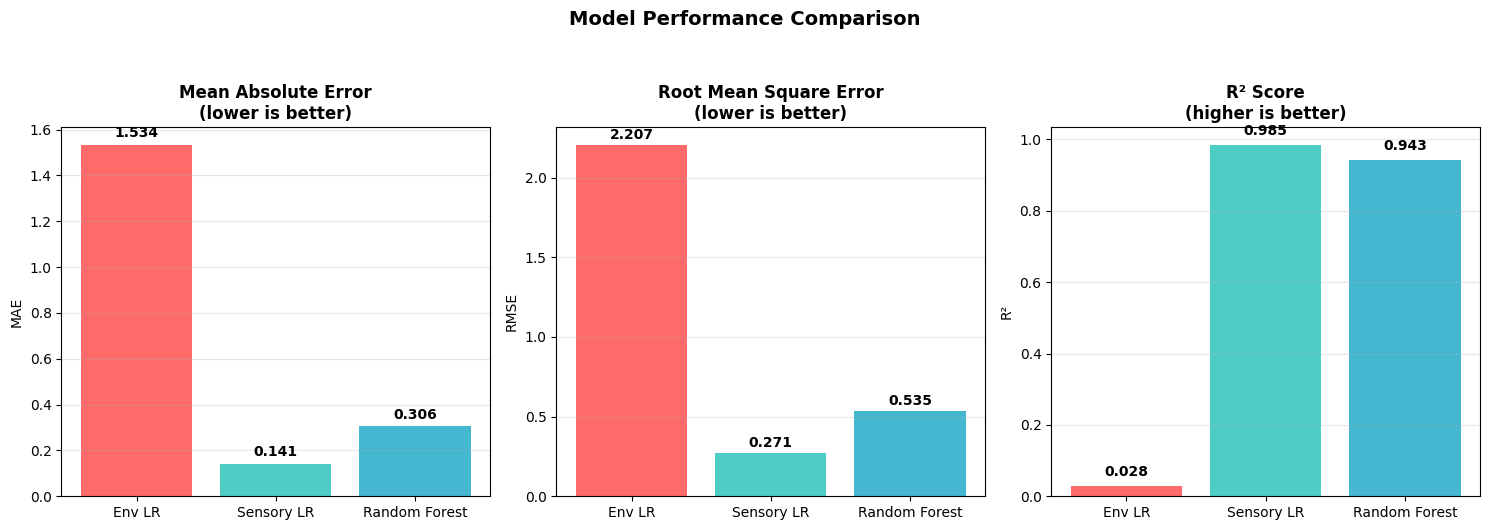


MODEL PERFORMANCE COMPARISON TABLE
                                  Model   MAE  RMSE    R²
Linear Regression (Altitude + Moisture) 1.534 2.207 0.028
            Linear Regression (Sensory) 0.141 0.271 0.985
                Random Forest (Sensory) 0.306 0.535 0.943


In [ ]:
# Model Performance Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Env LR', 'Sensory LR', 'Random Forest']
mae_values = [1.534, 0.141, 0.306]
rmse_values = [2.207, 0.271, 0.535]
r2_values = [0.028, 0.985, 0.943]

# Colors
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# MAE comparison (lower is better)
bars1 = axes[0].bar(models, mae_values, color=colors)
axes[0].set_title('Mean Absolute Error\n(lower is better)', fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].grid(True, alpha=0.3, axis='y')
# Add value labels
for bar, val in zip(bars1, mae_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE comparison (lower is better)
bars2 = axes[1].bar(models, rmse_values, color=colors)
axes[1].set_title('Root Mean Square Error\n(lower is better)', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].grid(True, alpha=0.3, axis='y')
# Add value labels
for bar, val in zip(bars2, rmse_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# R² comparison (higher is better)
bars3 = axes[2].bar(models, r2_values, color=colors)
axes[2].set_title('R² Score\n(higher is better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].grid(True, alpha=0.3, axis='y')
# Add value labels
for bar, val in zip(bars3, r2_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figure10_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison table
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON TABLE")
print("="*70)
comparison_display = comparison.copy()
comparison_display['MAE'] = comparison_display['MAE'].round(3)
comparison_display['RMSE'] = comparison_display['RMSE'].round(3)
comparison_display['R²'] = comparison_display['R²'].round(3)
print(comparison_display.to_string(index=False))